# CAMM Hackathon #10: STEM Image Restoration

STEM image credits: Austin Houston


In [13]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
!gdown https://drive.google.com/file/d/14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /Users/utkarshpratiush/project/camm-hack-13th-mar-2026/camm-hack-27-mar-2026/graphene_2.h5
100%|██████████████████████████████████████| 17.1M/17.1M [00:00<00:00, 23.9MB/s]


In [3]:
!gdown https://drive.google.com/file/d/1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /Users/utkarshpratiush/project/camm-hack-13th-mar-2026/camm-hack-27-mar-2026/HAADF_21.h5
100%|██████████████████████████████████████| 4.53M/4.53M [00:00<00:00, 13.0MB/s]


In [14]:
#@title h5 load
def save_dict_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'w') as f:
        _recursively_save(f, data_dict)

def _recursively_save(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            subgroup = group.create_group(str(key))
            _recursively_save(subgroup, value)

    elif isinstance(data, list):
        # Turn list into group with numerical keys
        for i, item in enumerate(data):
            subgroup = group.create_group(str(i))
            _recursively_save(subgroup, item)

    elif isinstance(data, np.ndarray):
        if data.dtype == object:
            # convert each element to string (json)
            data_as_str = np.array([json.dumps(x) for x in data], dtype='S256')
            group.create_dataset('value', data=data_as_str)
        else:
            group.create_dataset('value', data=data)

    elif isinstance(data, (int, float, np.int_, np.float_)):
        group.create_dataset('value', data=data)

    elif data is None:
        group.attrs['value'] = 'None'

    else:
        # Fallback: convert unknown object to JSON string
        group.create_dataset('value', data=json.dumps(data))


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)



def _load_item(obj):
    """
    Load any HDF5 object (Group or Dataset) and reconstruct Python object.
    """
    # ---------------------------------------------------------
    # CASE 1 — HDF5 GROUP  (recursive dict or list)
    # ---------------------------------------------------------
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())

        # Empty group → return None or empty dict
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}

        # Detect list: all keys are integers
        if all(k.isdigit() for k in keys):
            lst = []
            for k in sorted(keys, key=lambda x: int(x)):
                lst.append(_load_item(obj[k]))
            return lst

        # Regular dictionary
        out = {}
        for k in keys:
            out[k] = _load_item(obj[k])

        # Special case: group representing None
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None

        return out

    # ---------------------------------------------------------
    # CASE 2 — HDF5 DATASET  (arrays / scalars / strings)
    # ---------------------------------------------------------
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]

        # Scalar
        if np.isscalar(data):
            return data

        # Byte strings → JSON or text
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except:
                return data.decode()

        # Array of byte strings
        if data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except:
                return [x.decode() for x in data]

        # Normal numpy array
        return data

    # ---------------------------------------------------------
    # CASE 3 — Attributes marking None
    # ---------------------------------------------------------
    else:
        raise ValueError("Unknown HDF5 object type:", obj)


def get_arr(runs, key):
    """
    Extract numpy array from runs[key], automatically handling nested {'value': array}.
    """
    val = runs[key]
    if isinstance(val, dict) and "value" in val:
        return np.asarray(val["value"])
    return np.asarray(val)



In [15]:
#@title masking functions
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line

def mask_below_line(im, row=None, frac=0.6, above=True):
    """
    Mask all pixels below (or above) a horizontal threshold row.

    Parameters
    ----------
    im : 2D array
    row   : int, absolute row index. Defaults to frac * H.
    frac  : float, fraction of height for the cut if row is None.
    above : bool, if True mask everything above the line instead.

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    H, W = im.shape
    if row is None:
        row = int(frac * H)
    mask = np.zeros((H, W), dtype=bool)
    if above:
        mask[:row, :] = True
    else:
        mask[row:, :] = True
    return mask

def mask_lakes(im, n_lakes=10, size_range=(10, 220), aspect_range=(0.5, 4.0),
               roughness=0.8, n_harmonics=34, seed=None):
    """
    Lake regions with ragged / torn borders, arranged in a loose cluster.

    The border is a polar curve whose radius is modulated by a sum of random
    sinusoids, producing irregular, non-repeating jagged edges.

    Parameters
    ----------
    im : 2D array
    n_lakes      : number of lakes
    size_range   : (min, max) semi-major axis in pixels
    aspect_range : (min, max) aspect ratio (semi-major / semi-minor)
    roughness    : 0 = smooth ellipse, 1 = very jagged (good range: 0.2–0.6)
    n_harmonics  : number of sinusoidal harmonics added to the border
    seed         : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    # loose cluster centre
    cy_c = rng.integers(H // 4, 3 * H // 4)
    cx_c = rng.integers(W // 4, 3 * W // 4)
    spread = max(H, W) // 4

    yy, xx = np.mgrid[:H, :W]

    for _ in range(n_lakes):
        cy = int(np.clip(rng.normal(cy_c, spread), 0, H - 1))
        cx = int(np.clip(rng.normal(cx_c, spread), 0, W - 1))
        a = rng.integers(*size_range)           # semi-major
        aspect = rng.uniform(*aspect_range)
        b = max(1, int(a / aspect))             # semi-minor
        angle = rng.uniform(0, np.pi)

        # rotate coordinates
        dy = yy - cy
        dx = xx - cx
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        u = cos_a * dx + sin_a * dy             # along major axis
        v = -sin_a * dx + cos_a * dy            # along minor axis

        # polar angle of every pixel relative to lake centre
        theta = np.arctan2(v, u)

        # ragged radius envelope: 1 + sum of random harmonics
        freqs = rng.integers(2, n_harmonics + 2, size=n_harmonics)
        amps  = rng.uniform(0, roughness / n_harmonics, size=n_harmonics)
        phases = rng.uniform(0, 2 * np.pi, size=n_harmonics)
        envelope = 1.0 + sum(
            amp * np.sin(freq * theta + phase)
            for amp, freq, phase in zip(amps, freqs, phases)
        )

        # pixel is inside if its normalised ellipse distance < ragged envelope
        dist = np.sqrt((u / a) ** 2 + (v / b) ** 2)
        mask |= dist <= envelope

    return ~mask

def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=None):
    """
    Thin random straight lines across the image (horizontal, vertical, or diagonal).

    Parameters
    ----------
    im : 2D array
    n_lines     : number of lines
    thickness   : line width in pixels (via dilation)
    orientation : "horizontal" | "vertical" | "diagonal" | "mixed"
    seed        : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        if orientation == "mixed":
            ort = rng.choice(orientations)
        else:
            ort = orientation

        if ort == "horizontal":
            r = rng.integers(0, H)
            mask[r, :] = True
        elif ort == "vertical":
            c = rng.integers(0, W)
            mask[:, c] = True
        else:  # diagonal
            r0, c0 = rng.integers(0, H), rng.integers(0, W)
            r1, c1 = rng.integers(0, H), rng.integers(0, W)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        struct = np.ones((thickness, thickness), dtype=bool)
        mask = binary_dilation(mask, structure=struct)

    return ~mask

def mask_small_blobs(im, n_blobs=300, size_range=(1, 24), seed=None):
    """
    Many tiny blobs simulating dead-pixel clusters or dust on the detector.

    Parameters
    ----------
    im      : 2D array
    n_blobs    : number of small blobs
    size_range : (min_r, max_r) radius in pixels
    seed       : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    yy, xx = np.ogrid[:H, :W]

    for _ in range(n_blobs):
        cy = rng.integers(0, H)
        cx = rng.integers(0, W)
        r = rng.integers(*size_range)
        mask |= (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2

    return ~mask

In [16]:
data = load_hdf5_to_dict('graphene_2.h5')
data_more = load_hdf5_to_dict('HAADF_21.h5')

im0 = data['Measurement_000']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im1 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im2 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, -1000:]
im3 = data_more['Measurement_000']['Channel_000']['HAADF']['HAADF']

ims = [im0, im1, im2, im3]

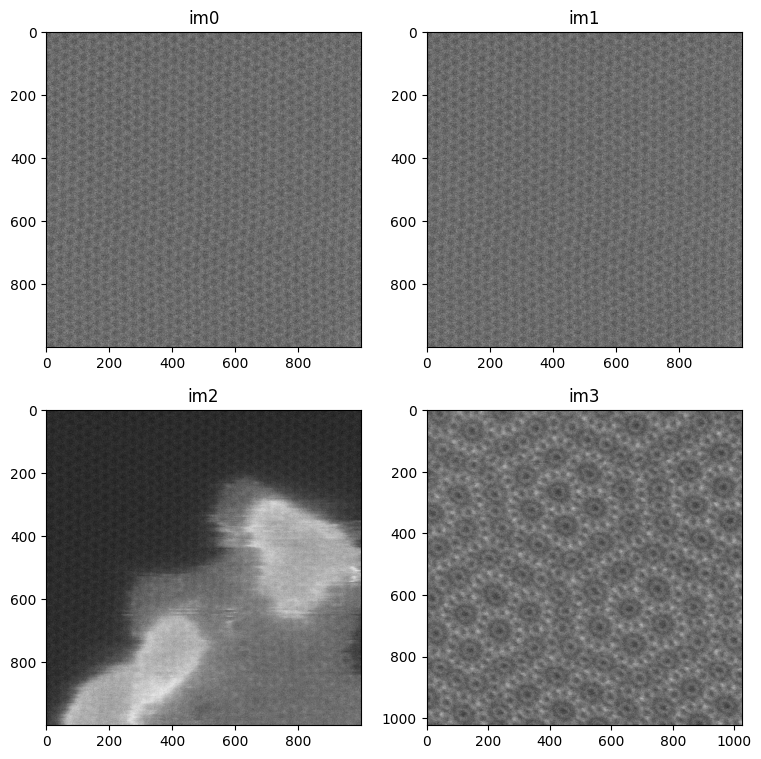

In [17]:
fig, axes = plt.subplots(2,2, figsize=(9,9))

ax = axes.flatten()

for i, _ in enumerate(ax):
  _.imshow(ims[i], cmap='gray')
  _.set_title(f'im{i}')

Text(0.5, 1.0, 'mask_small_blobs()')

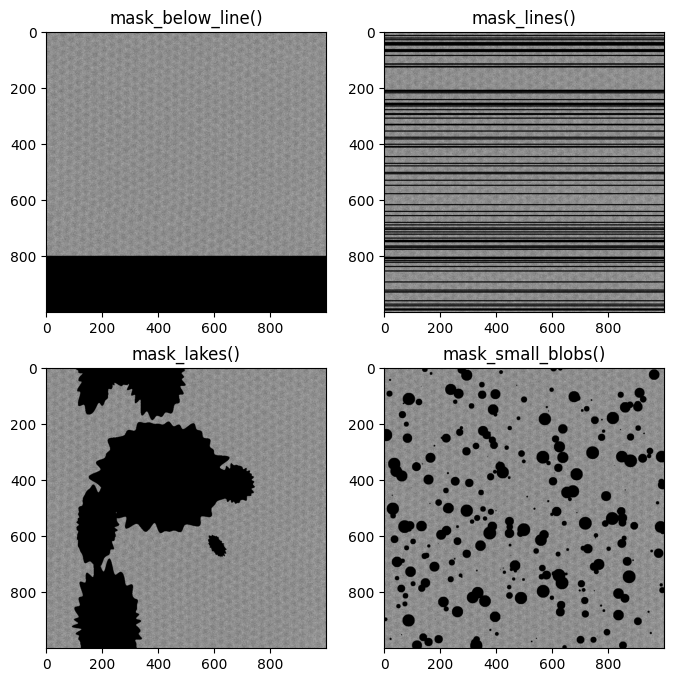

: 

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(8,8))


ax[0,0].imshow(mask_below_line(im0, frac=0.8)*im0, cmap='gray')
ax[0,0].set_title('mask_below_line()')

ax[0,1].imshow(mask_lines(im0)*im0, cmap='gray')
ax[0,1].set_title('mask_lines()')

ax[1,0].imshow(mask_lakes(im0)*im0, cmap='gray')
ax[1,0].set_title('mask_lakes()')

ax[1,1].imshow(mask_small_blobs(im0)*im0, cmap='gray')
ax[1,1].set_title('mask_small_blobs()')


# Given a 2D microscopy intensity array and a binary loss mask, reconstruct missing regions and estimate prediction uncertainty

In [18]:
#your code

## Utkarsh attempts with LLM help

Q1. What do you think importance of this problem?? - what is it called in the literature?
```
Why it matters:
STEM/electron microscopy images are expensive to acquire (beam damage, drift, time), so recovering corrupted or partially-sampled data is critical for materials science discoveries.
In the literature this is called:

Image Inpainting — the core problem (filling missing regions)
Compressed Sensing / Sparse Reconstruction — when missing pixels are structured
Blind Image Restoration — when the degradation model is unknown
Uncertainty Quantification (UQ) — the second part of the challenge

More specifically in microscopy:

STEM image denoising/reconstruction
Undersampled STEM reconstruction — deliberately skip pixels to reduce beam damage, then reconstruct
This connects to dose-efficient imaging, a hot topic in electron microscopy

Key methods you'd find in literature:

Dictionary learning / NMF
Deep learning inpainting (U-Net, diffusion models)
Gaussian Processes (natural UQ)
Total Variation minimization
Non-local means

The UQ aspect is especially important — in science you don't just want a pretty reconstructed image, you want to know where you can trust the reconstruction.
```

Q2. which methods give reasonable uncertiaity estimates?

```
Methods with principled uncertainty estimates:
Best / most principled:

Gaussian Processes — gold standard for UQ, gives exact posterior uncertainty, but scales poorly (O(n³)) with image size
Bayesian Neural Networks — principled but hard to train
Diffusion Models — sample multiple reconstructions, take variance as uncertainty — very strong currently

Practical & popular:

Monte Carlo Dropout — run inference N times with dropout on, take variance. Easy to add to any neural net
Deep Ensembles — train N networks, take disagreement as uncertainty. Simple and works well empirically
Normalizing Flows — give full predictive distribution

Classical / interpretable:

Kriging (spatial GP) — actually very natural for images, gives variance maps directly
Sparse Bayesian learning / relevance vector machines

Honest ranking for this microscopy problem:
MethodUQ QualityScalabilityEaseDiffusion models⭐⭐⭐⭐⭐⭐Deep Ensembles⭐⭐⭐⭐⭐⭐⭐GP/Kriging⭐⭐⭐⭐⭐⭐MC Dropout⭐⭐⭐⭐⭐⭐⭐
For a hackathon, deep ensembles or MC dropout are pragmatic. For publication-quality UQ, GPs or diffusion models.
```

Q3. Is Diffusion model correct way to do this?
```
No as the model training might not be on stem images
```

Q4. How to use GP?
```
Core idea: GP treats the image as a spatial function — nearby pixels are correlated. You fit on known pixels, predict missing ones with uncertainty.
The problem: 1000×1000 image = 1M pixels, GP is O(n³) — won't work naively.
Solution — patch-based GP:
```

Q5. I think its kind of similar to LLM - pretraining problem where you mask the words and it is asked to predict it and learns to make a sentence - thats what I recall in bert paper

```
Yes! Great analogy — you're thinking of Masked Language Modeling (MLM) from BERT. The parallel is really clean:
BERTSTEM InpaintingMask random tokensMask random pixelsPredict masked words from contextPredict missing pixels from neighborsContext = surrounding sentenceContext = surrounding pixel intensitiesLearns language structureExploits spatial correlation
But key differences:
1. What "context" means:

BERT — context is sequential + semantic ("the cat sat on the ___")
Image — context is purely spatial/local, no semantics

2. Supervision:

BERT learns a general representation useful for many tasks
GP inpainting is purely generative, no learned representation

3. Uncertainty:

BERT gives no uncertainty on masked token predictions
GP gives principled uncertainty — this is where GP wins

The deeper connection is actually to autoencoders and masked autoencoders (MAE) — He et al. 2022 did exactly this for images: mask 75% of patches, reconstruct them with a ViT. Very successful and directly analogous to your problem.
MAE would actually be a strong baseline here — pretrain on the microscopy images themselves, fine-tune on reconstruction. Worth noting in your hackathon writeup as a natural extension.
```

Q6. can a vae be used here? - vae also has uncertianity in latent sapce? -


```
Yes! VAE is very natural here. Let me break it down:
How VAE fits this problem:
Encoder: masked image → μ, σ (latent distribution)
Decoder: z ~ N(μ,σ) → reconstructed image
The mask can be fed as an additional channel so the encoder knows what's missing.

Where uncertainty comes from in VAE:
SourceWhat it capturesLatent σUncertainty in content/style — what should be thereDecoder varianceUncertainty in pixel values given contentMultiple samples from zSpread of plausible reconstructions
So you sample z multiple times → get multiple reconstructions → pixel-wise std = uncertainty map. This is called Monte Carlo uncertainty.

VAE vs GP for this problem:
VAEGPUQ sourceLatent space samplingPosterior varianceScales to large images✅ easily❌ strugglesPrincipled UQ⚠️ approximate✅ exactNeeds training data✅ yes❌ noCaptures global structure✅ yes❌ local onlyInterpretable❌✅

The key limitation of VAE uncertainty:
VAE latent σ is not calibrated — it's regularized toward N(0,1) by the KL term, not toward true predictive uncertainty. So:

GP std has a precise probabilistic meaning
VAE std is more of a relative confidence measure


Best of both worlds — recent work:

VAEGP — GP prior in latent space, combines global structure + principled UQ
Conditional VAE (CVAE) — condition on observed pixels explicitly, stronger than vanilla VAE for inpainting


For your hackathon:
VAE is worth trying as it would complement GP nicely — GP is better for small missing regions (lines, blobs), VAE potentially better for large missing regions (lakes, below_line) where GP has no nearby context to interpolate from.
```

Q7. I'm wondering how to actually formulate this problem as a graph denoising kind of that each pixel or patch is a node in the graph and then the connection is the neighborhood. And then the problem becomes that you mask some regions, basically those nodes, and the information from the neighborhoods is useful to create the demasking. Are denoising, do you think such ideas exist?
```
Yes — this is a real and sensible formulation. In the literature it is usually closer to graph-based image inpainting / graph signal reconstruction than “denoising” strictly, though the math overlaps a lot.

A clean formulation is:

Nodes = pixels or patches
Edges = spatial neighbors, and optionally nonlocal similar patches
Signal on node = intensity, feature vector, or latent embedding
Mask = set of missing/unobserved nodes
Goal = infer values on masked nodes from observed neighbors and graph structure

In equations, if 
𝑥
x is the image signal on the graph and 
𝑀
M selects observed nodes, a classic objective is:

	​
∥M(x−y)∥
2
+λx
⊤
Lx

where 
𝑦
y is the corrupted image and 
𝐿
L is the graph Laplacian.
The first term keeps known pixels fixed; the second enforces graph smoothness, meaning connected nodes should have compatible values. This is the core graph-signal view of inpainting/restoration.

There are two useful graph choices:

Pixel graph
Good for small missing regions and local continuity.
Patch graph
Usually better for microscopy, because patches can connect not just nearby regions but also structurally similar regions elsewhere in the image. That captures repeated lattice motifs, particles, edges, etc. Nonlocal self-similarity has long been important in restoration.

And yes, modern variants exist too:

Graph convolution / hypergraph methods for inpainting
Masked modeling methods, where part of the image is hidden and the model learns to predict it from context
Diffusion / generative inpainting methods for larger semantic holes

For your STEM case, I would think of it like this:

node = small patch embedding, not raw pixel
edges = nearby patches + similar patches by descriptor
observed nodes = unmasked patches
missing nodes = corrupted patches
reconstruction = message passing / Laplacian interpolation / GNN decoder

So: yes, the idea exists, and your intuition is basically right. The best phrasing is probably:

“masked-region reconstruction on a pixel/patch graph using local and nonlocal neighborhood information.”

If you want, I can write a minimal mathematical formulation specifically for STEM image restoration.
```

## Lets do GP based resonstruction and see

In [53]:
# !pip install botorch

In [20]:
import torch
from botorch.models import SingleTaskGP
from gpytorch.kernels import (
    RBFKernel, MaternKernel, RQKernel,
    ScaleKernel, AdditiveKernel
)
from gpytorch.likelihoods import GaussianLikelihood
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood

In [21]:
kernels = {
    'RBF': ScaleKernel(RBFKernel()),
    'Matern_0.5': ScaleKernel(MaternKernel(nu=0.5)),
    'Matern_1.5': ScaleKernel(MaternKernel(nu=1.5)),
    'Matern_2.5': ScaleKernel(MaternKernel(nu=2.5)),
    'RQ': ScaleKernel(RQKernel()),
    'RBF+Matern': ScaleKernel(RBFKernel()) + ScaleKernel(MaternKernel(nu=2.5)),
}

In [30]:
def fit_gp_patch(known_coords, known_vals, missing_coords, kernel):
    """
    known_coords  : (N, 2) tensor
    known_vals    : (N, 1) tensor
    missing_coords: (M, 2) tensor
    """
    # Cast everything to float64 as recommended by BoTorch
    known_coords   = known_coords.double()
    known_vals     = known_vals.double()
    missing_coords = missing_coords.double()

    # Normalize coords to [0,1]
    known_coords   = known_coords   / known_coords.max()
    missing_coords = missing_coords / known_coords.max()

    # Skip degenerate patches (near-constant signal)
    if known_vals.std() < 1e-6:
        mean = known_vals.mean().expand(missing_coords.shape[0])
        std  = torch.zeros(missing_coords.shape[0], dtype=torch.float64)
        return mean, std

    likelihood = GaussianLikelihood()
    model = SingleTaskGP(
        known_coords,
        known_vals,
        likelihood=likelihood,
        covar_module=kernel
    )

    mll = ExactMarginalLogLikelihood(likelihood, model)

    try:
        fit_gpytorch_mll(mll)
    except Exception:
        pass  # fall back to unoptimized prior — still gives predictions

    model.eval()
    likelihood.eval()

    with torch.no_grad():
        pred = likelihood(model(missing_coords))
        mean = pred.mean
        std  = pred.variance.clamp(min=0).sqrt()

    return mean, std

In [31]:
from skimage.metrics import structural_similarity as ssim_metric
import torch

def compute_psnr(true, pred, mask):
    """
    Compute PSNR only on missing (masked) pixels.
    mask: bool array, True = known, False = missing
    """
    missing = ~mask  # pixels we reconstructed
    mse = np.mean((true[missing] - pred[missing]) ** 2)
    if mse == 0:
        return float('inf')
    max_val = true.max()
    return 20 * np.log10(max_val / np.sqrt(mse))


def compute_ssim(true, pred, mask):
    """
    SSIM over full image — skimage handles 2D arrays directly.
    data_range important for non [0,1] images.
    """
    return ssim_metric(
        true, 
        pred, 
        data_range=true.max() - true.min()
    )


def compute_nll(true, pred_mean, pred_std, mask):
    """
    Negative log likelihood under Gaussian predictive distribution.
    Lower = better calibrated uncertainty.
    Only evaluated on missing pixels.
    """
    missing = ~mask
    residuals = true[missing] - pred_mean[missing]
    std = pred_std[missing]
    nll = 0.5 * np.log(2 * np.pi * std**2) + (residuals**2) / (2 * std**2)
    return nll.mean()

def calibration_score(true, pred, std, mask):
    """
    Good UQ: residuals should fall within
    predicted confidence intervals
    ~68% within 1std, ~95% within 2std
    """
    residuals = (true - pred)[~mask]
    std_vals = std[~mask]
    
    within_1std = (np.abs(residuals) < std_vals).mean()
    within_2std = (np.abs(residuals) < 2*std_vals).mean()
    
    return {'within_1std': within_1std, 
            'within_2std': within_2std}

In [32]:
def patch_gp(im, mask, kernel, patch_size=32, stride=16, max_known=200):
    """
    im        : 2D numpy array (H, W)
    mask      : bool array, True=known, False=missing
    kernel    : gpytorch kernel
    max_known : subsample known pixels per patch for speed
    """
    H, W = im.shape
    recon       = im.copy().astype(np.float32)
    uncertainty = np.zeros_like(recon)
    counts      = np.zeros_like(recon)  # for averaging overlaps

    # Normalize image to [0,1]
    im_min, im_max = im.min(), im.max()
    im_norm = (im - im_min) / (im_max - im_min)

    for r in range(0, H - patch_size + 1, stride):
        for c in range(0, W - patch_size + 1, stride):

            # Extract patch
            patch      = im_norm[r:r+patch_size, c:c+patch_size]
            patch_mask = mask[r:r+patch_size,    c:c+patch_size]

            known_idx   = np.argwhere(patch_mask)        # known pixels
            missing_idx = np.argwhere(~patch_mask)       # missing pixels

            # Skip if nothing to predict or nothing to train on
            if len(missing_idx) == 0 or len(known_idx) < 5:
                continue

            # Subsample known pixels for speed
            if len(known_idx) > max_known:
                chosen = np.random.choice(len(known_idx), max_known, replace=False)
                known_idx = known_idx[chosen]

            # Build tensors
            known_coords   = torch.tensor(known_idx,   dtype=torch.float32)
            known_vals     = torch.tensor(patch[known_idx[:,0],   known_idx[:,1]],
                                          dtype=torch.float32).unsqueeze(-1)
            missing_coords = torch.tensor(missing_idx, dtype=torch.float32)

            # Normalize coords to [0,1]
            known_coords   = known_coords   / patch_size
            missing_coords = missing_coords / patch_size

            # Fit and predict
            try:
                mean, std = fit_gp_patch(known_coords, known_vals, 
                                          missing_coords, kernel)
            except Exception as e:
                print(f"  GP failed at patch ({r},{c}): {e}")
                continue

            mean = mean.numpy().flatten()
            std  = std.numpy().flatten()

            # Denormalize predictions back to original scale
            mean = mean * (im_max - im_min) + im_min

            # Accumulate predictions (handle overlaps by averaging)
            rows = missing_idx[:, 0] + r
            cols = missing_idx[:, 1] + c
            recon[rows, cols]       += mean
            uncertainty[rows, cols] += std
            counts[rows, cols]      += 1

    # Average overlapping predictions
    predicted = counts > 0
    recon[predicted]       /= counts[predicted]
    uncertainty[predicted] /= counts[predicted]

    # Where nothing was predicted, keep original
    recon[mask] = im[mask]

    return recon, uncertainty

In [33]:

def compute_all_metrics(true, pred_mean, pred_std, mask):
    return {
        'psnr'        : compute_psnr(true, pred_mean, mask),
        'ssim'        : compute_ssim(true, pred_mean, mask),
        'nll'         : compute_nll(true, pred_mean, pred_std, mask),
        'calibration' : calibration_score(true, pred_mean, pred_std, mask)
    }

def compare_kernels(im, mask, patch_size=32, stride=16):
    results = {}
    
    for name, kernel in kernels.items():
        print(f"Running {name}...")
        recon, uncertainty = patch_gp(im, mask, kernel, 
                                       patch_size, stride)
        
        # Metrics
        metrics = compute_all_metrics(im, recon, uncertainty, mask)
        
        results[name] = {
            'recon'       : recon,
            'uncertainty' : uncertainty,
            **metrics      # unpacks psnr, ssim, nll, calibration
        }
    
    return results

In [34]:
def plot_comparison(results, im, mask):
    n = len(results)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    
    for i, (name, res) in enumerate(results.items()):
        axes[i,0].imshow(res['recon'], cmap='gray')
        axes[i,0].set_title(f'{name} | PSNR:{res["psnr"]:.1f}')
        
        axes[i,1].imshow(res['uncertainty'], cmap='hot')
        axes[i,1].set_title('Uncertainty (std)')
        
        axes[i,2].imshow(np.abs(im - res['recon']), cmap='hot')
        axes[i,2].set_title('Residual |true - pred|')

/var/folders/t8/2by8vp4d4dxb7gt4wv0pwbsh0000gn/T/ipykernel_67789/3010810059.py:38: RuntimeWarning: divide by zero encountered in log
  nll = 0.5 * np.log(2 * np.pi * std**2) + (residuals**2) / (2 * std**2)
/var/folders/t8/2by8vp4d4dxb7gt4wv0pwbsh0000gn/T/ipykernel_67789/3010810059.py:38: RuntimeWarning: invalid value encountered in divide
  nll = 0.5 * np.log(2 * np.pi * std**2) + (residuals**2) / (2 * std**2)


Running RBF+Matern...


/var/folders/t8/2by8vp4d4dxb7gt4wv0pwbsh0000gn/T/ipykernel_67789/3010810059.py:38: RuntimeWarning: divide by zero encountered in log
  nll = 0.5 * np.log(2 * np.pi * std**2) + (residuals**2) / (2 * std**2)
/var/folders/t8/2by8vp4d4dxb7gt4wv0pwbsh0000gn/T/ipykernel_67789/3010810059.py:38: RuntimeWarning: invalid value encountered in divide
  nll = 0.5 * np.log(2 * np.pi * std**2) + (residuals**2) / (2 * std**2)


Kernel                   PSNR     SSIM      NLL   1-std%   2-std%
------------------------------------------------------------
RBF                     14.62   0.7277      nan    0.00%    0.00%
Matern_0.5              14.62   0.7277      nan    0.00%    0.00%
Matern_1.5              14.62   0.7277      nan    0.00%    0.00%
Matern_2.5              14.62   0.7276      nan    0.00%    0.00%
RQ                      14.62   0.7277      nan    0.00%    0.00%
RBF+Matern              14.62   0.7277      nan    0.00%    0.00%


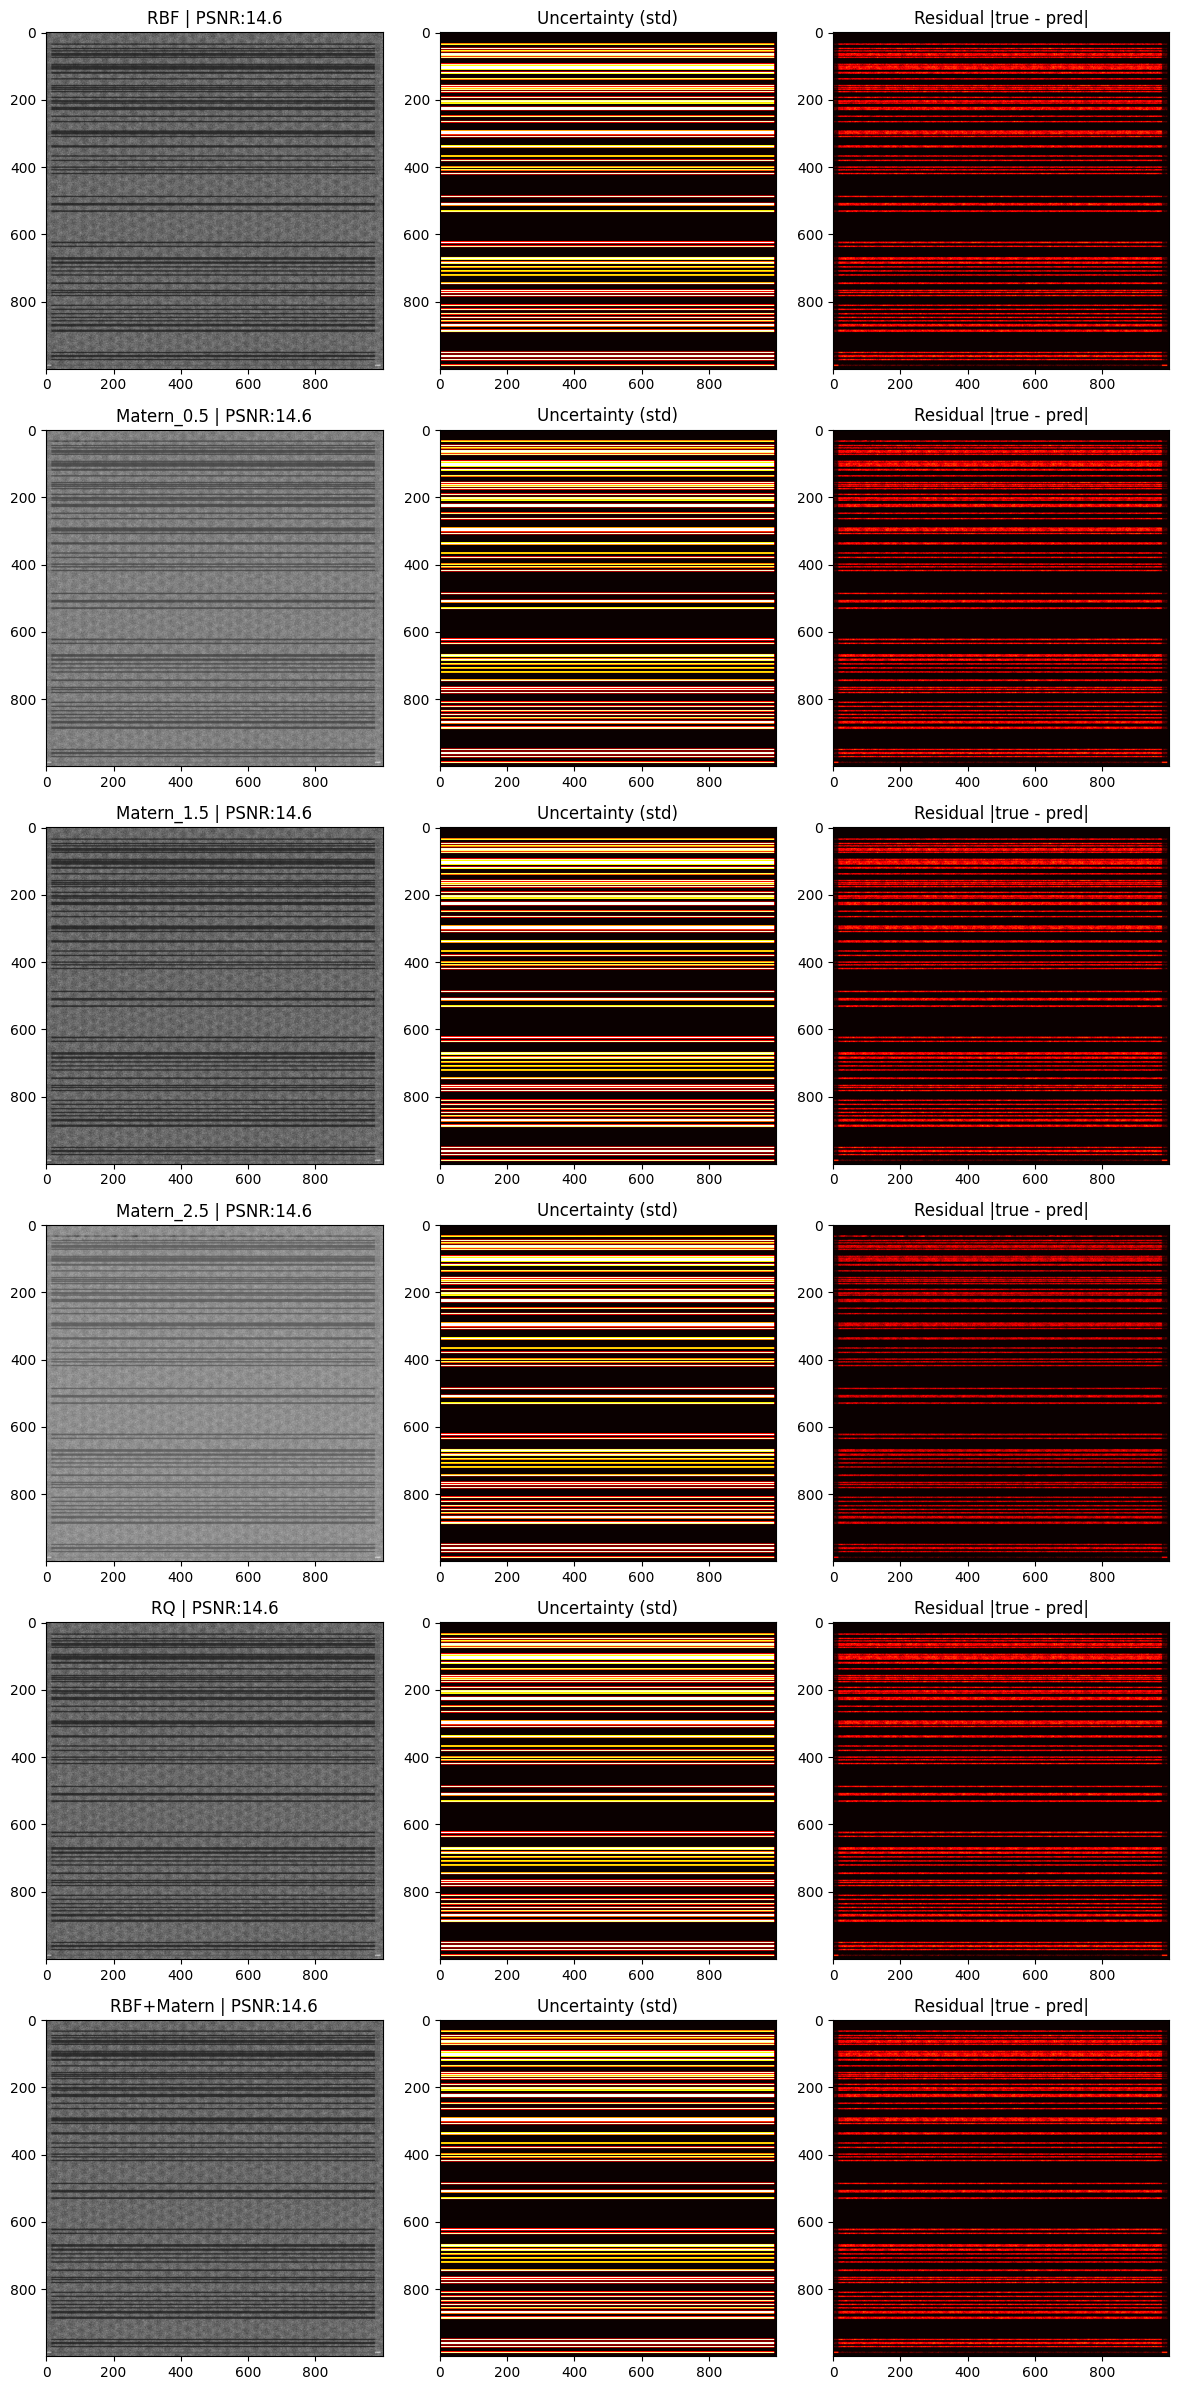

In [35]:
# Pick an image and mask type to start
im   = im0
mask = mask_lines(im0)   # or mask_lakes, mask_small_blobs, mask_below_line

# Run comparison
results = compare_kernels(im, mask, patch_size=32, stride=16)

# Print metrics table
print(f"{'Kernel':<20} {'PSNR':>8} {'SSIM':>8} {'NLL':>8} {'1-std%':>8} {'2-std%':>8}")
print("-" * 60)
for name, res in results.items():
    calib = res['calibration']
    print(f"{name:<20} {res['psnr']:>8.2f} {res['ssim']:>8.4f} "
          f"{res['nll']:>8.4f} {calib['within_1std']:>8.2%} "
          f"{calib['within_2std']:>8.2%}")

# Visualize
plot_comparison(results, im, mask)
plt.tight_layout()
plt.show()

## cVAE

Epoch   0 | Loss: -2772859.76
Epoch  20 | Loss: -10060338.57
Epoch  40 | Loss: -10175719.36
Epoch  60 | Loss: -10217505.65
Epoch  80 | Loss: -10366660.05
Epoch 100 | Loss: -10357878.15
Epoch 120 | Loss: -10384789.99
Epoch 140 | Loss: -10406390.39
Epoch 160 | Loss: -10430474.46
Epoch 180 | Loss: -10452215.83


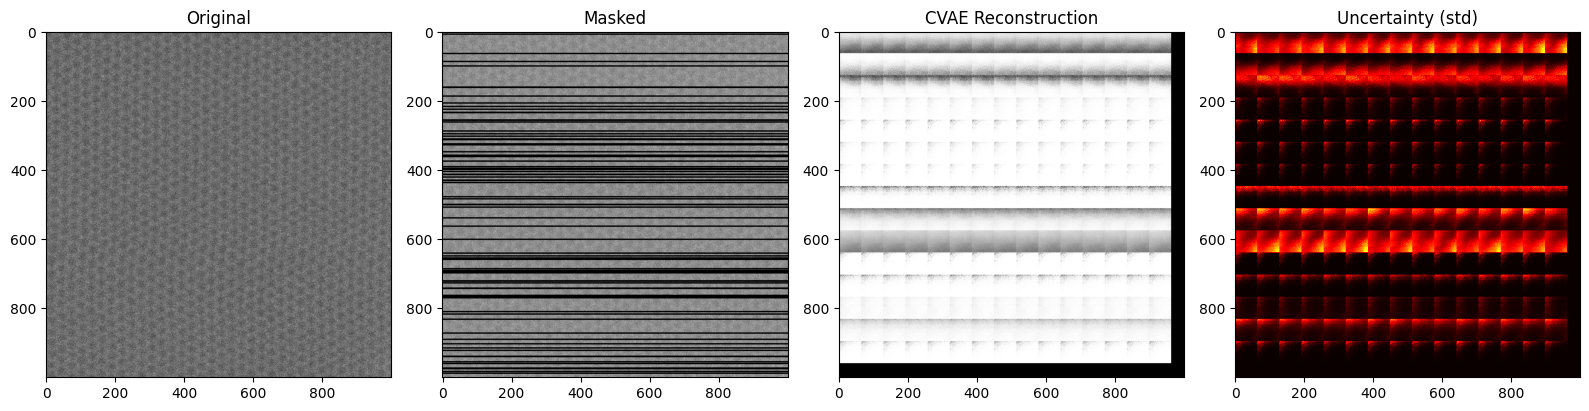

In [ ]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

# ── 1. DATA ──────────────────────────────────────────────────────────────
def make_patches(ims, patch_size=64, n_patches=2000):
    patches = []
    for _ in range(n_patches):
        im  = ims[np.random.randint(len(ims))]
        r   = np.random.randint(0, im.shape[0] - patch_size)
        c   = np.random.randint(0, im.shape[1] - patch_size)
        patches.append(im[r:r+patch_size, c:c+patch_size])
    patches = np.array(patches, dtype=np.float32)
    # normalize to [0,1]
    patches = (patches - patches.min()) / (patches.max() - patches.min())
    return torch.tensor(patches)

def apply_random_mask(patches):
    """randomly zero out ~50% of pixels, return (masked, mask)"""
    mask    = (torch.rand_like(patches) > 0.5).float()
    masked  = patches * mask
    return masked, mask

patches    = make_patches(ims)                          # (N, 64, 64)
P          = patches.shape[1] * patches.shape[2]        # 64*64 = 4096
loader     = DataLoader(TensorDataset(patches), batch_size=64, shuffle=True)

# ── 2. MODEL ─────────────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, in_dim, z_dim, h=256):
        super().__init__()
        self.net   = nn.Sequential(nn.Linear(in_dim, h), nn.ReLU(),
                                   nn.Linear(h, h),      nn.ReLU())
        self.mu    = nn.Linear(h, z_dim)
        self.logvar= nn.Linear(h, z_dim)

    def forward(self, x):
        h        = self.net(x)
        return self.mu(h), torch.exp(0.5 * self.logvar(h))

class Decoder(nn.Module):
    def __init__(self, z_dim, out_dim, h=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(z_dim,  h), nn.ReLU(),
                                 nn.Linear(h,       h), nn.ReLU(),
                                 nn.Linear(h, out_dim), nn.Sigmoid())

    def forward(self, z):
        return self.net(z)

class CVAE(nn.Module):
    def __init__(self, p_dim, z_dim=32):
        super().__init__()
        # encoder sees: masked_image + mask (2*P dims)
        self.encoder = Encoder(2 * p_dim, z_dim)
        # decoder sees: z + masked_image + mask
        self.decoder = Decoder(z_dim + 2 * p_dim, p_dim)
        self.p_dim   = p_dim
        self.z_dim   = z_dim

                
    def model(self, x, masked, mask):
        pyro.module("cvae", self)
        B = x.shape[0]
        with pyro.plate("data", B):
            z_prior = dist.Normal(
                x.new_zeros(B, self.z_dim),
                x.new_ones(B,  self.z_dim)
            ).to_event(1)
            z      = pyro.sample("z", z_prior)
            inp    = torch.cat([z, masked, mask], dim=1)
            mu_out = self.decoder(inp)

            # only compute likelihood on missing pixels
            missing   = (1 - mask).bool()
            mu_miss   = mu_out[missing]
            x_miss    = x[missing]

            pyro.sample("obs",
                        dist.Normal(mu_miss, 0.1).to_event(1),
                        obs=x_miss)

    def guide(self, x, masked, mask):
        pyro.module("cvae", self)
        B   = x.shape[0]
        inp = torch.cat([masked, mask], dim=1)
        mu, scale = self.encoder(inp)
        with pyro.plate("data", B):
            pyro.sample("z", dist.Normal(mu, scale).to_event(1))


# ── 3. TRAIN ─────────────────────────────────────────────────────────────

# cvae      = CVAE(p_dim=P, z_dim=32)
# optimizer = Adam({"lr": 1e-3})
# svi       = SVI(cvae.model, cvae.guide, optimizer, loss=Trace_ELBO())

from pyro.optim import ClippedAdam

pyro.clear_param_store()
cvae      = CVAE(p_dim=P, z_dim=32)
optimizer = ClippedAdam({"lr": 1e-3, "lrd": 0.9999})  # lrd = lr decay per step
svi       = SVI(cvae.model, cvae.guide, optimizer, loss=Trace_ELBO())

for epoch in range(200):                         # more epochs
    total_loss = 0
    for (batch,) in loader:
        masked, mask = apply_random_mask(batch)
        x      = batch.view(-1, P)
        masked = masked.view(-1, P)
        mask   = mask.view(-1, P)
        total_loss += svi.step(x, masked, mask)
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {total_loss/len(loader):.2f}")

# ── 4. PREDICT + UNCERTAINTY ─────────────────────────────────────────────
def predict_with_uncertainty(cvae, masked_im, mask_im, patch_size=64, n_samples=50):
    """
    Runs CVAE patch-by-patch, stitches results back.
    masked_im, mask_im : 2D numpy arrays (H, W)
    returns mean, std  : 2D numpy arrays (H, W)
    """
    H, W       = masked_im.shape
    mean_full  = np.zeros((H, W), dtype=np.float32)
    std_full   = np.zeros((H, W), dtype=np.float32)
    counts     = np.zeros((H, W), dtype=np.float32)

    cvae.eval()
    with torch.no_grad():
        for r in range(0, H - patch_size + 1, patch_size):
            for c in range(0, W - patch_size + 1, patch_size):

                patch  = masked_im[r:r+patch_size, c:c+patch_size]
                pmask  = mask_im[r:r+patch_size,   c:c+patch_size]

                masked_t = torch.tensor(patch.flatten(),  dtype=torch.float32).unsqueeze(0)
                mask_t   = torch.tensor(pmask.flatten(),  dtype=torch.float32).unsqueeze(0)

                samples = []
                for _ in range(n_samples):
                    z     = torch.randn(1, cvae.z_dim)
                    inp   = torch.cat([z, masked_t, mask_t], dim=1)
                    recon = cvae.decoder(inp)
                    samples.append(recon.numpy())

                samples = np.array(samples).squeeze()    # (n_samples, P)
                mean_full[r:r+patch_size, c:c+patch_size] += samples.mean(axis=0).reshape(patch_size, patch_size)
                std_full[r:r+patch_size,  c:c+patch_size] += samples.std(axis=0).reshape(patch_size, patch_size)
                counts[r:r+patch_size,    c:c+patch_size] += 1

    # average overlaps
    mean_full /= np.maximum(counts, 1)
    std_full  /= np.maximum(counts, 1)

    return mean_full, std_full

# ── 5. RUN ────────────────────────────────────────────────────────────────
mask_im    = mask_lines(im0)
masked_im  = im0 * mask_im
# normalize
im_min, im_max = im0.min(), im0.max()
masked_norm    = (masked_im - im_min) / (im_max - im_min)

mean, std = predict_with_uncertainty(cvae, masked_norm, mask_im.astype(np.float32))

# denormalize mean back
mean = mean * (im_max - im_min) + im_min

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(im0,         cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(masked_im,   cmap='gray'); axes[1].set_title('Masked')
axes[2].imshow(mean,        cmap='gray'); axes[2].set_title('CVAE Reconstruction')
axes[3].imshow(std,         cmap='hot');  axes[3].set_title('Uncertainty (std)')
plt.tight_layout()
plt.show()

Epoch   0 | Loss: 0.0071
Epoch  20 | Loss: 0.0020
Epoch  40 | Loss: 0.0020
Epoch  60 | Loss: 0.0019
Epoch  80 | Loss: 0.0019
Epoch 100 | Loss: 0.0019
Epoch 120 | Loss: 0.0019
Epoch 140 | Loss: 0.0019
Epoch 160 | Loss: 0.0019
Epoch 180 | Loss: 0.0019
Epoch 200 | Loss: 0.0019
Epoch 220 | Loss: 0.0019
Epoch 240 | Loss: 0.0019
Epoch 260 | Loss: 0.0019
Epoch 280 | Loss: 0.0019
Epoch 300 | Loss: 0.0018
Epoch 320 | Loss: 0.0018
Epoch 340 | Loss: 0.0019
Epoch 360 | Loss: 0.0018
Epoch 380 | Loss: 0.0018
Epoch 400 | Loss: 0.0018
Epoch 420 | Loss: 0.0018
Epoch 440 | Loss: 0.0018
Epoch 460 | Loss: 0.0018
Epoch 480 | Loss: 0.0018


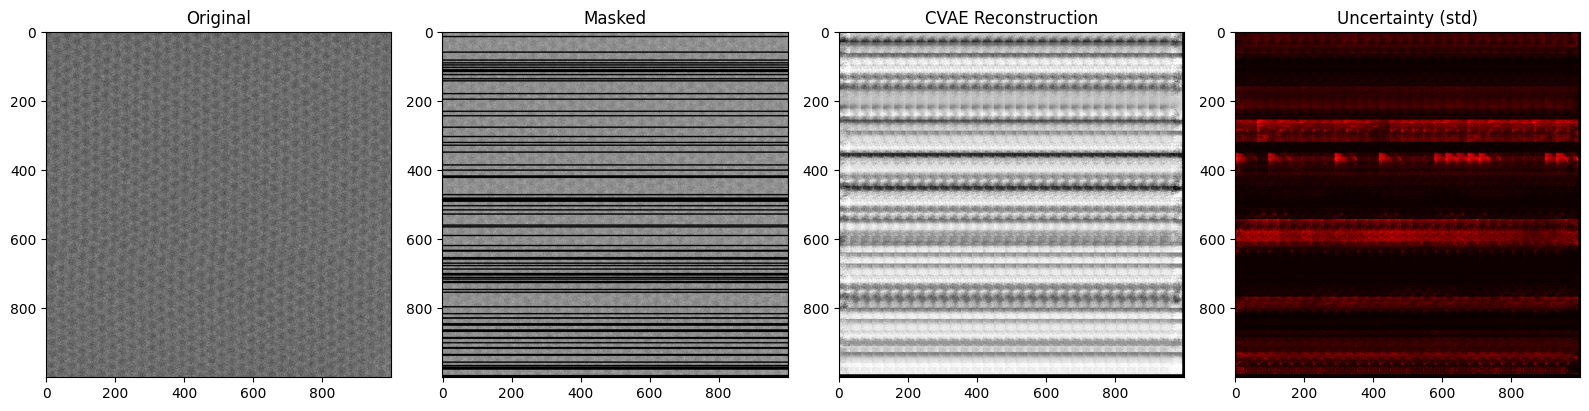

In [50]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

# ── 1. DATA ──────────────────────────────────────────────────────────────
def make_patches(ims, patch_size=64, n_patches=2000):
    patches = []
    for _ in range(n_patches):
        im  = ims[np.random.randint(len(ims))]
        r   = np.random.randint(0, im.shape[0] - patch_size)
        c   = np.random.randint(0, im.shape[1] - patch_size)
        patches.append(im[r:r+patch_size, c:c+patch_size])
    patches = np.array(patches, dtype=np.float32)
    # normalize to [0,1]
    patches = (patches - patches.min()) / (patches.max() - patches.min())
    return torch.tensor(patches)

def apply_random_mask(patches):
    """randomly zero out ~50% of pixels, return (masked, mask)"""
    mask    = (torch.rand_like(patches) > 0.5).float()
    masked  = patches * mask
    return masked, mask

patches = make_patches(ims, patch_size=64, n_patches=10000)  # was 2000
P          = patches.shape[1] * patches.shape[2]        # 64*64 = 4096
loader     = DataLoader(TensorDataset(patches), batch_size=64, shuffle=True)

# ── 2. MODEL ─────────────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, in_dim, z_dim, h=256):
        super().__init__()
        self.net    = nn.Sequential(nn.Linear(in_dim, h), nn.ReLU(),
                                    nn.Linear(h, h),      nn.ReLU())
        self.mu     = nn.Linear(h, z_dim)
        self.logvar = nn.Linear(h, z_dim)   # ← renamed from before

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)

class Decoder(nn.Module):
    def __init__(self, z_dim, out_dim, h=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(z_dim,  h), nn.ReLU(),
                                 nn.Linear(h,       h), nn.ReLU(),
                                 nn.Linear(h, out_dim), nn.Sigmoid())

    def forward(self, z):
        return self.net(z)

class CVAE(nn.Module):
    def __init__(self, p_dim, z_dim=32):
        super().__init__()
        self.encoder = Encoder(2 * p_dim, z_dim)
        self.decoder = Decoder(z_dim + 2 * p_dim, p_dim)
        self.p_dim   = p_dim
        self.z_dim   = z_dim

    def forward(self, x, masked, mask):
        # encode
        inp        = torch.cat([masked, mask], dim=1)
        mu, logvar = self.encoder_mu_logvar(inp)
        std        = torch.exp(0.5 * logvar)
        eps        = torch.randn_like(std)
        z          = mu + eps * std

        # decode
        dec_inp    = torch.cat([z, masked, mask], dim=1)
        recon      = self.decoder(dec_inp)

        return recon, mu, std

    def encoder_mu_logvar(self, inp):
        h      = self.encoder.net(inp)
        return self.encoder.mu(h), self.encoder.logvar(h)


def cvae_loss(recon, x, mu, std, mask):
    missing     = (1 - mask)                              # 1 = missing pixel
    # reconstruction loss only on missing pixels
    recon_loss  = (missing * (recon - x) ** 2).sum() / missing.sum()
    # KL divergence
    kl          = -0.5 * (1 + 2*std.log() - mu**2 - std**2).sum(dim=1).mean()
    return recon_loss + 0.001 * kl              


# ── 3. TRAIN ─────────────────────────────────────────────────────────────

# cvae      = CVAE(p_dim=P, z_dim=32)
# optimizer = Adam({"lr": 1e-3})
# svi       = SVI(cvae.model, cvae.guide, optimizer, loss=Trace_ELBO())

# ── drop Pyro SVI entirely, use plain PyTorch optimizer ──
pyro.clear_param_store()
cvae      = CVAE(p_dim=P, z_dim=32)
optimizer = torch.optim.Adam(cvae.parameters(), lr=1e-3)

for epoch in range(500):
    total_loss = 0
    for (batch,) in loader:
        masked, mask = apply_random_mask(batch)
        x      = batch.view(-1, P)
        masked = masked.view(-1, P)
        mask   = mask.view(-1, P)

        recon, mu, std = cvae(x, masked, mask)
        loss           = cvae_loss(recon, x, mu, std, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {total_loss/len(loader):.4f}")

# ── 4. PREDICT + UNCERTAINTY ─────────────────────────────────────────────
def predict_with_uncertainty(cvae, masked_im, mask_im, patch_size=64, n_samples=50):
    H, W       = masked_im.shape
    mean_full  = np.zeros((H, W), dtype=np.float32)
    std_full   = np.zeros((H, W), dtype=np.float32)
    counts     = np.zeros((H, W), dtype=np.float32)

    stride = patch_size // 2                             # ← added here

    cvae.eval()
    with torch.no_grad():
        for r in range(0, H - patch_size + 1, stride):  # ← was patch_size
            for c in range(0, W - patch_size + 1, stride):  # ← was patch_size

                patch  = masked_im[r:r+patch_size, c:c+patch_size]
                pmask  = mask_im[r:r+patch_size,   c:c+patch_size]

                masked_t = torch.tensor(patch.flatten(),  dtype=torch.float32).unsqueeze(0)
                mask_t   = torch.tensor(pmask.flatten(),  dtype=torch.float32).unsqueeze(0)

                samples = []
                for _ in range(n_samples):
                    z     = torch.randn(1, cvae.z_dim)
                    inp   = torch.cat([z, masked_t, mask_t], dim=1)
                    recon = cvae.decoder(inp)
                    samples.append(recon.numpy())

                samples = np.array(samples).squeeze()
                mean_full[r:r+patch_size, c:c+patch_size] += samples.mean(axis=0).reshape(patch_size, patch_size)
                std_full[r:r+patch_size,  c:c+patch_size] += samples.std(axis=0).reshape(patch_size, patch_size)
                counts[r:r+patch_size,    c:c+patch_size] += 1

    # averaging overlaps naturally blends patch boundaries
    mean_full /= np.maximum(counts, 1)
    std_full  /= np.maximum(counts, 1)

    return mean_full, std_full

# ── 5. RUN ────────────────────────────────────────────────────────────────
mask_im    = mask_lines(im0)
masked_im  = im0 * mask_im
# normalize
im_min, im_max = im0.min(), im0.max()
masked_norm    = (masked_im - im_min) / (im_max - im_min)

mean, std = predict_with_uncertainty(cvae, masked_norm, mask_im.astype(np.float32))

# denormalize mean back
mean = mean * (im_max - im_min) + im_min

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(im0,         cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(masked_im,   cmap='gray'); axes[1].set_title('Masked')
axes[2].imshow(mean,        cmap='gray'); axes[2].set_title('CVAE Reconstruction')
axes[3].imshow(std,         cmap='hot');  axes[3].set_title('Uncertainty (std)')
plt.tight_layout()
plt.show()

In [44]:
from skimage.restoration import inpaint_biharmonic

def inpaint_skimage(im, mask):
    """
    mask : True = known, False = missing
    skimage expects: True = missing
    """
    # normalize
    im_min, im_max = im.min(), im.max()
    im_norm = (im - im_min) / (im_max - im_min)
    
    recon = inpaint_biharmonic(im_norm, ~mask)   # note: flipped mask
    recon = recon * (im_max - im_min) + im_min   # denormalize
    return recon

In [47]:
def plot_method(im, mask, recon, std=None, title=''):
    """
    Reusable plot for any method.
    std optional — if None shows residual instead.
    """
    masked_im = im * mask

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(im,        cmap='gray'); axes[0].set_title('Original')
    axes[1].imshow(masked_im, cmap='gray'); axes[1].set_title('Masked')
    axes[2].imshow(recon,     cmap='gray'); axes[2].set_title(f'{title} Reconstruction')

    if std is not None:
        axes[3].imshow(std,              cmap='hot'); axes[3].set_title('Uncertainty (std)')
    else:
        axes[3].imshow(np.abs(im-recon), cmap='hot'); axes[3].set_title('|Residual|')

    for ax in axes: ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [48]:
ski_recon = inpaint_skimage(im0, mask_im)


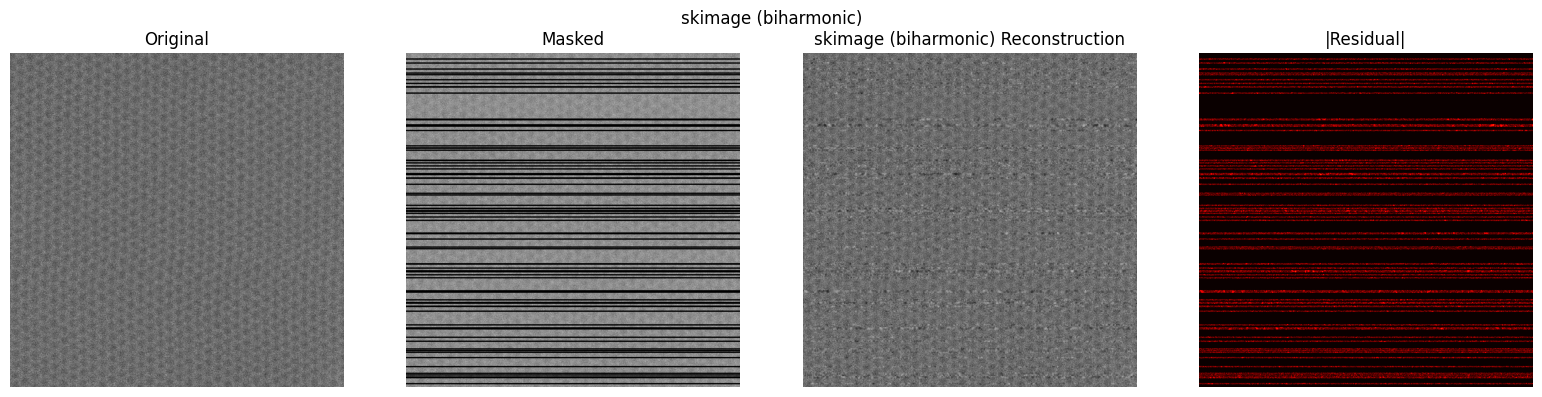

In [49]:
plot_method(im0, mask_im, ski_recon, std=None, title='skimage (biharmonic)')


## GNN - frame image inpainting as a GNN problem
Graph construction:
- Each patch (e.g. 16x16) = one node  
- Edges = spatial neighbors (up, down, left, right + diagonal)    
- Node features = patch pixel values + mask   
- Edge features = spatial distance / intensity similarity 

Message passing intuition:
- Known patch → sends its signal to neighboring unknown patches
- Unknown patch → aggregates messages from all neighbors
- After K rounds → unknown patches have received info from K-hop neighborhood

Architecture:
Input node features:
  - patch pixels (flattened) : 16*16 = 256 dims
  - mask                     : 256 dims
  - is_known flag            : 1 dim
  Total per node             : 513 dims

GNN layers (e.g. 3x GraphSAGE or GAT):
  - aggregate neighbor features
  - update node representation

Output head:
  - MLP → reconstruct missing patch pixels
  - MLP → predict uncertainty (std)


Epoch   0 | Loss: 0.0076
Epoch  20 | Loss: -0.0660
Epoch  40 | Loss: -0.0679
Epoch  60 | Loss: -0.0688
Epoch  80 | Loss: -0.0684
Epoch 100 | Loss: -0.0643
Epoch 120 | Loss: -0.0685
Epoch 140 | Loss: -0.0691
Epoch 160 | Loss: -0.0693
Epoch 180 | Loss: -0.0694


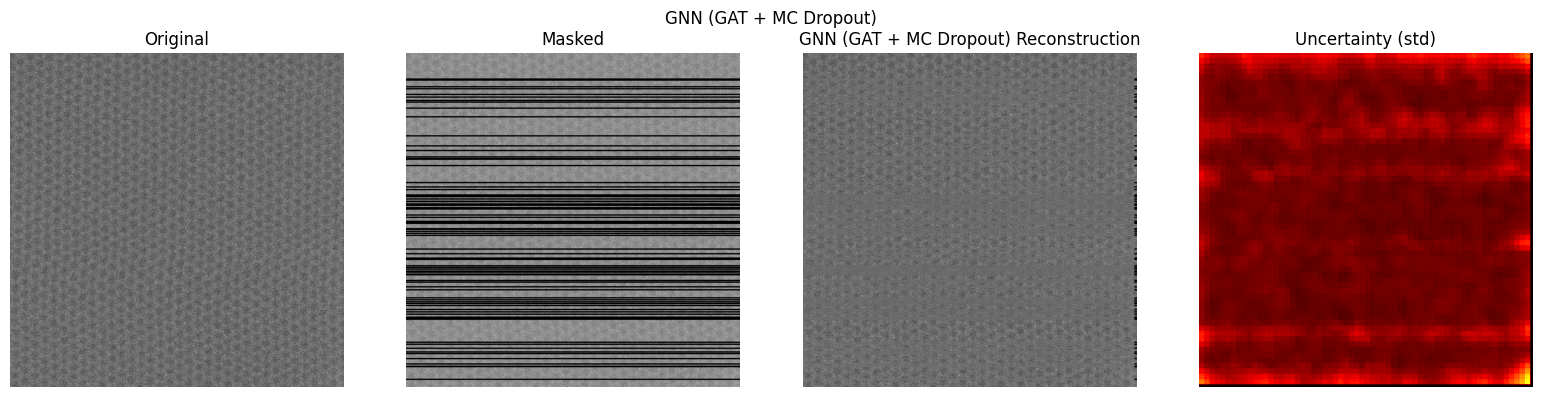

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

# ── 1. BUILD GRAPH FROM IMAGE ─────────────────────────────────────────────
def image_to_graph(im, mask, patch_size=16):
    """
    im, mask : 2D numpy arrays (H, W)
    Returns  : PyG Data object
    """
    H, W = im.shape
    # normalize
    im_min, im_max = im.min(), im.max()
    im_norm = (im - im_min) / (im_max - im_min)

    n_row = H // patch_size
    n_col = W // patch_size

    node_features = []
    node_is_known = []

    # ── node features ────────────────────────────────────────────────────
    for i in range(n_row):
        for j in range(n_col):
            r, c    = i * patch_size, j * patch_size
            patch   = im_norm[r:r+patch_size, c:c+patch_size].flatten()
            pmask   = mask[r:r+patch_size,    c:c+patch_size].flatten().astype(np.float32)
            is_known= float(pmask.mean() > 0.5)   # 1 if mostly known

            # features: [masked_patch, mask, is_known_flag]
            feat = np.concatenate([patch * pmask, pmask, [is_known]])
            node_features.append(feat)
            node_is_known.append(is_known)

    node_features = torch.tensor(np.array(node_features), dtype=torch.float32)
    node_is_known = torch.tensor(node_is_known,            dtype=torch.float32)

    # ── edges (8-connectivity between patches) ───────────────────────────
    edge_src, edge_dst = [], []
    for i in range(n_row):
        for j in range(n_col):
            node_id = i * n_col + j
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n_row and 0 <= nj < n_col:
                        edge_src.append(node_id)
                        edge_dst.append(ni * n_col + nj)

    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)

    # ── targets: true patch pixels ───────────────────────────────────────
    targets = []
    for i in range(n_row):
        for j in range(n_col):
            r, c = i * patch_size, j * patch_size
            targets.append(im_norm[r:r+patch_size, c:c+patch_size].flatten())
    targets = torch.tensor(np.array(targets), dtype=torch.float32)

    return Data(
        x          = node_features,
        edge_index = edge_index,
        y          = targets,
        is_known   = node_is_known,
        n_row      = n_row,
        n_col      = n_col,
    ), im_min, im_max


# ── 2. GNN MODEL ──────────────────────────────────────────────────────────
class InpaintGNN(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=256, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        self.conv1 = GATConv(in_dim,         hidden, heads=heads,     dropout=dropout)
        self.conv2 = GATConv(hidden * heads,  hidden, heads=heads,     dropout=dropout)
        self.conv3 = GATConv(hidden * heads,  hidden, heads=1,         dropout=dropout)

        # output heads
        self.recon_head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim), nn.Sigmoid()
        )
        self.std_head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim), nn.Softplus()  # always positive
        )

    def forward(self, data, training=False):
        x, edge_index = data.x, data.edge_index

        # MC dropout — keep dropout on even at inference if training=False
        x = F.dropout(x, p=self.dropout, training=True)   # always on for MC
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=True)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=True)
        x = F.elu(self.conv3(x, edge_index))

        recon = self.recon_head(x)
        std   = self.std_head(x)
        return recon, std


# ── 3. TRAINING ───────────────────────────────────────────────────────────
def train_gnn(ims, patch_size=16, epochs=200, lr=1e-3):
    """Train on all images with random masks"""

    # build one graph per image with random mask
    graphs = []
    for im in ims:
        mask  = (np.random.rand(*im.shape) > 0.5)   # random 50% mask
        graph, _, _ = image_to_graph(im, mask, patch_size)
        graphs.append(graph)

    P       = patch_size * patch_size
    in_dim  = P + P + 1            # masked_patch + mask + is_known flag
    model   = InpaintGNN(in_dim=in_dim, hidden=128, out_dim=P)
    optim   = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for graph in graphs:
            recon, std = model(graph)

            # only supervise missing nodes
            missing    = (graph.is_known < 0.5)
            if missing.sum() == 0:
                continue

            recon_loss = F.mse_loss(recon[missing], graph.y[missing])
            # NLL loss — encourage well calibrated std
            nll_loss   = (0.5 * ((graph.y[missing] - recon[missing])**2 / (std[missing]**2 + 1e-6)
                         + torch.log(std[missing] + 1e-6))).mean()

            loss = recon_loss + 0.1 * nll_loss
            optim.zero_grad()
            loss.backward()
            optim.step()
            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | Loss: {total_loss/len(graphs):.4f}")

    return model


# ── 4. PREDICT + UNCERTAINTY ──────────────────────────────────────────────
def predict_gnn(model, im, mask, patch_size=16, n_samples=50):
    """
    Returns mean, std reconstructions as 2D arrays (H, W)
    """
    graph, im_min, im_max = image_to_graph(im, mask, patch_size)
    H, W  = im.shape
    n_row = H // patch_size
    n_col = W // patch_size

    # MC dropout samples
    all_recons = []
    model.eval()                        # batchnorm off but dropout stays on
    with torch.no_grad():
        for _ in range(n_samples):
            recon, _ = model(graph)
            all_recons.append(recon.numpy())

    all_recons = np.array(all_recons)   # (n_samples, n_nodes, P)
    mean_nodes = all_recons.mean(axis=0)
    std_nodes  = all_recons.std(axis=0)

    # stitch patches back into full image
    mean_im = np.zeros((H, W), dtype=np.float32)
    std_im  = np.zeros((H, W), dtype=np.float32)

    for i in range(n_row):
        for j in range(n_col):
            node_id = i * n_col + j
            r, c    = i * patch_size, j * patch_size
            mean_im[r:r+patch_size, c:c+patch_size] = mean_nodes[node_id].reshape(patch_size, patch_size)
            std_im[r:r+patch_size,  c:c+patch_size] = std_nodes[node_id].reshape(patch_size, patch_size)

    # denormalize
    mean_im = mean_im * (im_max - im_min) + im_min

    # keep known pixels from original
    mean_im[mask] = im[mask]

    return mean_im, std_im


# ── 5. RUN ────────────────────────────────────────────────────────────────
# train
gnn_model = train_gnn(ims, patch_size=16, epochs=200)

# predict
mask_im    = mask_lines(im0)
gnn_mean, gnn_std = predict_gnn(gnn_model, im0, mask_im, patch_size=16)

# plot
plot_method(im0, mask_im, gnn_mean, std=gnn_std, title='GNN (GAT + MC Dropout)')

## learnings
- traditional skimage based method are fast and works good at reconstruction
- cvae?? - doesnt perform well - data hungry? need more images? 
    - observation - loss saturates fast --> so not enough data?

- gp based method
    - not performing well in first go 

- graph based mehod(GNN)?
    - reconstruction - looks intermediate b/w skimage and cvae
    - observation - loss saturates fast --> so not enough data?
    - good to see reducing patch size effects
- training time
    - cvae is the slowest to train - 30 mins for 500 epochs
    - skimage based method is fastest - no training
    - GNN- 5 minutes for 200 epochs - not bad when compared to cvae

- More thoughts
    - as a human I would think iterms of :
        - finding the repeating unit and then using it to inpaint (gloabal repeating unit if it exists - FFT will do it)
        - if no repeating unit then try to find local patterns and inpaint using it 
        - basically : paint(x_to_x+5_pixels given localities)
        - localities can be defined in differnt ways - if graph or something else

- SVK: try 
    - with image with circular masks and lets see how uncertainity changes at the cicrculr masks at the center
